# Hands-on: Blockchain Data Collection with The Graph

This notebook shows how to:

1. Connect to a subgraph through The Graph API
2. Explore the GraphQL schema and available entities
3. Query current onchain-indexed data
4. Pull historical snapshot data
5. Fetch more detailed current data from the same subgraph

> In The Graph, the equivalent of "tables" are usually **entities** exposed through a GraphQL schema.

In [1]:
# If needed:
# %pip install requests pandas matplotlib

import os
import json
import time

from dotenv import load_dotenv
load_dotenv()

import requests
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import utils

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# Common subgraphs

In [2]:
ids = {
    "Curve": "3fy93eAT56UJsRCEht8iFhfi6wjHWXtZ9dnnbQmvFopF",
    "Uniswap": "5zvR82QoaXYFyDEKLZ9t6v9adgnptxYpKpSbxtgVENFV",
    "AAVE": "JCNWRypm7FYwV8fx5HhzZPSFaMxgkPuw4TnR3Gpi81zk",
    "Chainlink": "39QtNcs7YrvJUvh2sNVGFTKLeahMBpB3BKWypPrSNYLc",
    "Polymarket": "81Dm16JjuFSrqz813HysXoUPvzTwE7fsfPk2RTf66nyC",
    "Polymarket_pnl": "6c58N5U4MtQE2Y8njfVrrAfRykzfqajMGeTMEvMmskVz"
}

#### Or find your own : [graph explorer](https://thegraph.com/explorer)

> We start with Uniswap, the main DEX on the ETH blockchain

# First Introduction

## Metadata and indexing

Subgraphs have to be queried using **graphql**. Using python requests library we can send a graphql query to the subgraph. 

> First we have a look at the subgraph metadata

In [61]:
# Set up environment
SUBGRAPH_ID = ids["Uniswap"]
API_KEY = os.getenv("GRAPH_API_KEY") 
SUBGRAPH_URL = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"
session = requests.Session()

In [4]:
# Basic function to run a GraphQL query against the subgraph
def run_query(query: str, variables: dict | None = None, url: str = SUBGRAPH_URL):
    payload = {
        "query": query,
        "variables": variables or {}
    }
    response = session.post(url, json=payload, timeout=60)
    response.raise_for_status()
    result = response.json()
    if "errors" in result:
        raise Exception(json.dumps(result["errors"], indent=2))
    return result["data"]

Start with a meta query.
It returns:
- the last indexed block
- the subgraph deployment id
- A boolean indicating indexing errors

In [5]:
META_QUERY = """
{
  _meta {
    deployment
    hasIndexingErrors
    block {
      number
      hash
      timestamp
    }
  }
}
"""

meta = run_query(META_QUERY)["_meta"]
meta


{'block': {'hash': '0x0b86da2005d365d7b864ccaf5707f67d43cae9b7895a15f07cc94e06db4d958e',
  'number': 24783244,
  'timestamp': 1775028323},
 'deployment': 'QmTZ8ejXJxRo7vDBS4uwqBeGoxLSWbhaA7oXa1RvxunLy7',
 'hasIndexingErrors': False}

In [6]:
meta = run_query(META_QUERY)["_meta"]
print("Last indexed block time: ", pd.to_datetime(meta['block']['timestamp'], unit = "s"))
print("Current time: ", datetime.datetime.now())

print("\n", (datetime.datetime.now()- pd.to_datetime(meta['block']['timestamp'], unit = "s")).seconds, "seconds since last indexed block.")

Last indexed block time:  2026-04-01 07:25:23
Current time:  2026-04-01 07:25:30.672575

 7 seconds since last indexed block.


New ETH blocks are mined in ~12 seconds intervals 

> Blocks are indexed in **UTC** time

Subgraph indexing is usually instant/very fast ! 

- You can check for other subgraphs

# View Data schema

Let us query the types defined on the Uniswap subgraphs and their properties.

In [7]:
INTROSPECTION_QUERY = """
query IntrospectSchema {
  __schema {
    queryType { name }
    types {
      name
      kind
      fields {
        name
        args {
          name
          type {
            kind
            name
            ofType {
              kind
              name
              ofType {
                kind
                name
                ofType {
                  kind
                  name
                }
              }
            }
          }
        }
        type {
          kind
          name
          ofType {
            kind
            name
            ofType {
              kind
              name
              ofType {
                kind
                name
              }
            }
          }
        }
      }
    }
  }
}
"""

schema = run_query(INTROSPECTION_QUERY)["__schema"]
print("Query type:", schema["queryType"]["name"])
print("Number of schema types:", len(schema["types"]))

Query type: Query
Number of schema types: 78


In [8]:
def pretty_type(t):
    if not t:
        return "UNKNOWN"
    kind = t.get("kind")
    name = t.get("name")
    of_type = t.get("ofType")
    if kind == "NON_NULL":
        return f"{pretty_type(of_type)}!"
    if kind == "LIST":
        return f"[{pretty_type(of_type)}]"
    return name or kind

def base_type_name(t):
    if not t:
        return None
    kind = t.get("kind")
    if kind in ("NON_NULL", "LIST"):
        return base_type_name(t.get("ofType"))
    return t.get("name")

In [9]:
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
3,bundles,[Bundle!]!,Bundle,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
19,burns,[Burn!]!,Burn,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
23,collects,[Collect!]!,Collect,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
1,factories,[Factory!]!,Factory,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
25,flashes,[Flash!]!,Flash,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
17,mints,[Mint!]!,Mint,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
29,poolDayDatas,[PoolDayData!]!,PoolDayData,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
31,poolHourDatas,[PoolHourData!]!,PoolHourData,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,pools,[Pool!]!,Pool,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
13,positionSnapshots,[PositionSnapshot!]!,PositionSnapshot,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True


The subgraphs defines types (like tables in SQL database): 
- singular are the basic components / plural are aggregated (need to query time/id...)
- each with a different schema : https://docs.uniswap.org/api/subgraph/overview

It is useful to look at the scema for a type of interest: 

In [10]:
def describe_type(type_name: str) -> pd.DataFrame:
    type_name = type_name[0].upper() + type_name[1:]
    t = types_by_name.get(type_name)
    if not t:
        raise ValueError(f"Type not found: {type_name}")
    if not t.get("fields"):
        return pd.DataFrame([{"message": f"Type {type_name} has no fields or is not an object type."}])

    rows = []
    for field in t["fields"]:
        rows.append({
            "field": field["name"],
            "type": pretty_type(field["type"]),
            "args": ", ".join(
                f"{a['name']}: {pretty_type(a['type'])}" for a in field.get("args", [])
            )
        })
    return pd.DataFrame(rows)

In [11]:
describe_type("pool")

,field,type,args
0,id,ID!,
1,createdAtTimestamp,BigInt!,
2,createdAtBlockNumber,BigInt!,
3,token0,Token!,
4,token1,Token!,
5,feeTier,BigInt!,
6,liquidity,BigInt!,
7,sqrtPrice,BigInt!,
8,feeGrowthGlobal0X128,BigInt!,
9,feeGrowthGlobal1X128,BigInt!,


- the **pool** type has global attributes (id, timestampCreated...) and aggregates to query :
    - Timestamp aligned(Hourly/Daily snapshots)
    - event aligned (Mints/Burns)

### Let's query the pool table

This first query collects basic information on the first 5 pools on the subgraph. 

> by default a type is queried in the subgraphs current state (at the last indexed block)
> An older state can be accessed by specifying the block number

In [12]:
POOL_QUERY = """
query GetPools($first: Int!) {
  pools(first: $first) {  
  id
  createdAtTimestamp
  liquidity
  token0Price
  token1Price
  }
  }
"""

run_query(POOL_QUERY, {"first": 5})

{'pools': [{'createdAtTimestamp': '1722420503',
   'id': '0x000024feb293b6c6c3a80a95f1f830a8746400b9',
   'liquidity': '0',
   'token0Price': '697.9687750256548431903030779836248',
   'token1Price': '0.001432728849457833648837565738741238'},
  {'createdAtTimestamp': '1687901099',
   'id': '0x0000d36ab86d213c14d93cd5ae78615a20596505',
   'liquidity': '0',
   'token0Price': '92751266.06890041657299158927228055',
   'token1Price': '0.00000001078152398757714537248724224771347'},
  {'createdAtTimestamp': '1746468647',
   'id': '0x00013bffe4c38c1372a450fac78b01cb4f554781',
   'liquidity': '2270652196042771771096799',
   'token0Price': '9503718.258500394602198428267165305',
   'token1Price': '0.0000001052219744735774017871522914893654'},
  {'createdAtTimestamp': '1626494775',
   'id': '0x0001fcbba8eb491c3ccfeddc5a5caba1a98c4c28',
   'liquidity': '303015134493562686441',
   'token0Price': '10001.64466212999659279505112078187',
   'token1Price': '0.00009998355608316876218708990103803189'},
  {'

### Let's look at the USDC/USDT pool


We can query more specific data on a single pool by using its ETH address

In [13]:
usdc_usdt_address = "0x3416cF6C708Da44DB2624D63ea0AAef7113527C6".lower()

POOL_QUERY = """
query GetPools($id: String!) {
  pool(id: $id) {  
  id
  createdAtTimestamp
  liquidity
  token0Price
  token1Price
  }
  }
"""

run_query(POOL_QUERY, {"id": usdc_usdt_address})

{'pool': {'createdAtTimestamp': '1636825557',
  'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6',
  'liquidity': '83568071443279250',
  'token0Price': '0.999566016912924467851182310088151',
  'token1Price': '1.000434171510167835031659954839869'}}

How can we verify which is token 0 and token 1 ? (Hint: check the schema, token0 and 1 are type Token) 

In [16]:
#describe_type("Token")
#...

### Get some historical data 

The pool entity has an indexed hourly data, look at its schema 

In [17]:
describe_type("poolHourData")

,field,type,args
0,id,ID!,
1,periodStartUnix,Int!,
2,pool,Pool!,
3,liquidity,BigInt!,
4,sqrtPrice,BigInt!,
5,token0Price,BigDecimal!,
6,token1Price,BigDecimal!,
7,tick,BigInt,
8,feeGrowthGlobal0X128,BigInt!,
9,feeGrowthGlobal1X128,BigInt!,


These are all the fields we can query hourly snapshots for. Note that detailed data (swaps, mints/burns and liqudity curve) are not indexed here.

In [18]:
POOL_QUERY = """
query GetHourlyPoolData($id: String!, $hourStartUnix: Int!) {
  poolHourDatas(first:1000, where: {periodStartUnix_gte: $hourStartUnix, pool: $id}, orderBy: periodStartUnix, orderDirection: asc) {  
  id
  liquidity
  periodStartUnix
  volumeUSD
  token0Price
  token1Price
  open
  high
  low
  close
  }
  }
"""

start_time = pd.to_datetime("2026-03-01").timestamp()

result = run_query(POOL_QUERY, {"id": usdc_usdt_address, "hourStartUnix": int(start_time)})
result_df = pd.DataFrame(result["poolHourDatas"])
result_df

,close,high,id,liquidity,low,open,periodStartUnix,token0Price,token1Price,volumeUSD
0,1.00007951064094916447034263254127,1.000080979573800872343383423514189,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492312,46547171483978045,1.000071638595434510359989005470383,1.000071980154968918024303596112039,1772323200,1.00007951064094916447034263254127,0.9999204956804902379779973020220245,277782.744785
1,1.000094413931863452366318027167694,1.000094685337667030750576483973498,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492313,46547171483978045,1.000079480381843494626532994468383,1.000079480381843494626532994468383,1772326800,1.000094413931863452366318027167694,0.9999055949812855521075107986908486,473438.0098805
2,1.000104262696705194341095042630769,1.000106128049688078191252936838328,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492314,40596476391285644,1.000094396185272084832056216734886,1.000094405993324202695283084006417,1772330400,1.000104262696705194341095042630769,0.9998957481728714385264613301238114,357202.868243
3,1.000116922937163134726907549586347,1.000116923074798375896710413696682,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492315,40596476391285644,1.000104234976096042419504493572762,1.000104262512105659792185238752731,1772334000,1.000116922937163134726907549586347,0.9998830907322118366566058693785643,434459.08155
4,1.00011244683444757761606019484537,1.000117394687055484759459274898207,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492316,40596476391285644,1.000108084465678532383515332168456,1.00011702107323672287331315827795,1772337600,1.00011244683444757761606019484537,0.9998875658084213490757256614055685,312427.4213214089604992939350523688
...,...,...,...,...,...,...,...,...,...,...
747,0.999499601302425402457499658408391,0.9994996015613773844997561382815932,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493059,59605110003835537,0.9994941592948870155965307390536062,0.9994941592965642997213164926110348,1775012400,0.999499601302425402457499658408391,1.000500649221793124557845143040146,167075.7855255
748,0.9995333328887370057024227800718172,0.9995346890212723230434666322269574,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493060,83568071443279250,0.9995119720231705167254527313922498,0.9995119720231705167254527313922498,1775016000,0.9995333328887370057024227800718172,1.000466884991133098429328005461939,1376783.737407
749,0.999535958948075014542747263238438,0.9995359713101863854906833564053242,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493061,83568071443279250,0.9995330874644405519632290882962556,0.9995333325031676787936578065583787,1775019600,0.999535958948075014542747263238438,1.000464256485993108696689084488976,150886.1499305
750,0.9995421321426317515045210600163632,0.999542531974885167383176547255087,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493062,83568071443279250,0.9995359665044364471691602783721106,0.9995359665044364471691602783721106,1775023200,0.9995421321426317515045210600163632,1.000458077596375809484720027017626,322917.8391230154163050590575491508


You can try longer periods:
- subgraphs often have a limit on how large a query can be (needs to be batched)
- Simple batching can be done with first and skip
> skip can also have a limit (batch with blocknumber/timestamp)

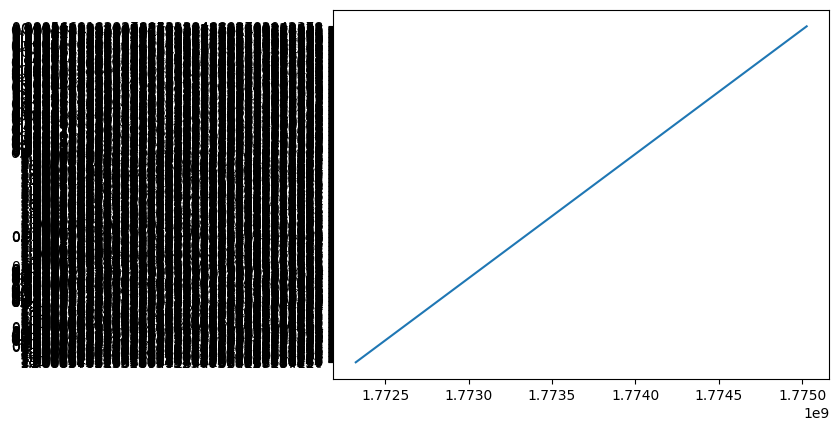

In [19]:
plt.plot(result_df["periodStartUnix"], result_df["token0Price"])

What is wrong here ? Fix the dataframe and plot again 

In [20]:
utils.clean_df(result_df)

,close,high,id,liquidity,low,open,periodStartUnix,token0Price,token1Price,volumeUSD
0,1.000080,1.000081,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492312,46547171483978045,1.000072,1.000072,2026-03-01 00:00:00,1.000080,0.999920,2.777827e+05
1,1.000094,1.000095,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492313,46547171483978045,1.000079,1.000079,2026-03-01 01:00:00,1.000094,0.999906,4.734380e+05
2,1.000104,1.000106,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492314,40596476391285644,1.000094,1.000094,2026-03-01 02:00:00,1.000104,0.999896,3.572029e+05
3,1.000117,1.000117,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492315,40596476391285644,1.000104,1.000104,2026-03-01 03:00:00,1.000117,0.999883,4.344591e+05
4,1.000112,1.000117,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492316,40596476391285644,1.000108,1.000117,2026-03-01 04:00:00,1.000112,0.999888,3.124274e+05
...,...,...,...,...,...,...,...,...,...,...
747,0.999500,0.999500,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493059,59605110003835537,0.999494,0.999494,2026-04-01 03:00:00,0.999500,1.000501,1.670758e+05
748,0.999533,0.999535,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493060,83568071443279250,0.999512,0.999512,2026-04-01 04:00:00,0.999533,1.000467,1.376784e+06
749,0.999536,0.999536,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493061,83568071443279250,0.999533,0.999533,2026-04-01 05:00:00,0.999536,1.000464,1.508861e+05
750,0.999542,0.999543,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493062,83568071443279250,0.999536,0.999536,2026-04-01 06:00:00,0.999542,1.000458,3.229178e+05


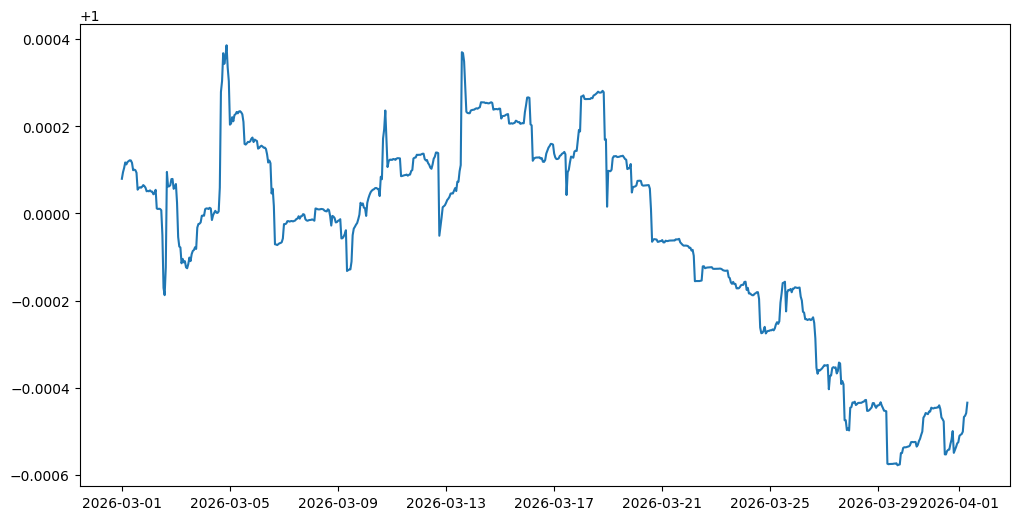

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(result_df["periodStartUnix"], result_df["token0Price"])

# Another application: get the current liquidity profile

## Direct per tick liquidity from Ticks

Let us query the current liqudity curve of the USDC/USDT pool and plot it :
- first find the current active tick (center of the liqudity curve)

In [59]:
POOL_STATE_QUERY = """
query PoolState($id: ID!) {
  pool(id: $id) {
    id
    tick
    liquidity
    token0 { symbol decimals }
    token1 { symbol decimals }
  }
}
"""

pool_state = run_query(POOL_STATE_QUERY, {"id": usdc_usdt_address})["pool"]
current_tick = int(pool_state["tick"])
print("Current tick:", current_tick)

# Define bounds for the liquidity query based on the current tick
lower = str(current_tick - 40)
upper = str(current_tick + 40)


Current tick: 4


Check what the *tick* type contains: 

In [62]:
describe_type("tick")

ValueError: Type not found: Tick

Query the liquidity curve : 
- Graphql allows querying around values (_gte, _le ...)
- Also allows ordering (similar to SQL)

In [54]:
LIQUIDITY_QUERY = """
query GetLiquidityCurve($id: ID!, $lower: BigInt!, $upper: BigInt!) {
  pool(id: $id) {
    id
    tick
    liquidity
    ticks(
      first: 1000
      where: {
        pool: $id
        tickIdx_gte: $lower
        tickIdx_lte: $upper
      }
      orderBy: tickIdx
      orderDirection: asc
    ) {
      id
      tickIdx
      price0
      price1
      liquidityNet
    }
}}
"""

In [55]:
raw = run_query(
    LIQUIDITY_QUERY,
    {"id": usdc_usdt_address, "lower": lower, "upper": upper}
)
ticks = pd.DataFrame(raw["pool"]["ticks"])
ticks.head()

NameError: name 'lower' is not defined

### Lets clean the data for plotting 

In [ ]:
ticks["tickIdx"] = ticks["tickIdx"].astype(int)
ticks["price0"] = pd.to_numeric(ticks["price0"], errors="coerce")
ticks["price1"] = pd.to_numeric(ticks["price1"], errors="coerce")
ticks["liquidityNet"] = pd.to_numeric(ticks["liquidityNet"], errors="coerce")

token0 = pool_state["token0"]["symbol"]
token1 = pool_state["token1"]["symbol"]
dec0 = int(pool_state["token0"]["decimals"])
dec1 = int(pool_state["token1"]["decimals"])

current_liquidity = float(raw['pool']["liquidity"])

In [ ]:
def build_active_liquidity_curve(ticks_df, current_tick, current_liquidity):
    ticks_df = ticks_df.sort_values("tickIdx").copy()

    below = ticks_df[ticks_df["tickIdx"] <= current_tick].sort_values("tickIdx", ascending=False).copy()
    above = ticks_df[ticks_df["tickIdx"] > current_tick].sort_values("tickIdx").copy()

    # move downward from current tick
    if not below.empty:
        below["activeLiquidity"] = current_liquidity - below["liquidityNet"].cumsum()
        below = below.sort_values("tickIdx")
    else:
        below["activeLiquidity"] = []

    # move upward from current tick
    if not above.empty:
        above["activeLiquidity"] = current_liquidity + above["liquidityNet"].cumsum()
    else:
        above["activeLiquidity"] = []

    curve = pd.concat([below, above], ignore_index=True).sort_values("tickIdx").reset_index(drop=True)
    return curve

curve = build_active_liquidity_curve(ticks, current_tick, current_liquidity)
curve.head()

,id,liquidityNet,price0,price1,tickIdx,activeLiquidity
0,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-35,0,0.996506,1.003506,-35,5.477241e+13
1,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-34,0,0.996606,1.003406,-34,5.477241e+13
2,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-33,4000897,0.996706,1.003305,-33,5.477241e+13
3,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-32,0,0.996805,1.003205,-32,5.477242e+13
4,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-31,5876297144,0.996905,1.003105,-31,5.477242e+13


Text(0.5, 0, 'Price of USDC in terms of USDT')

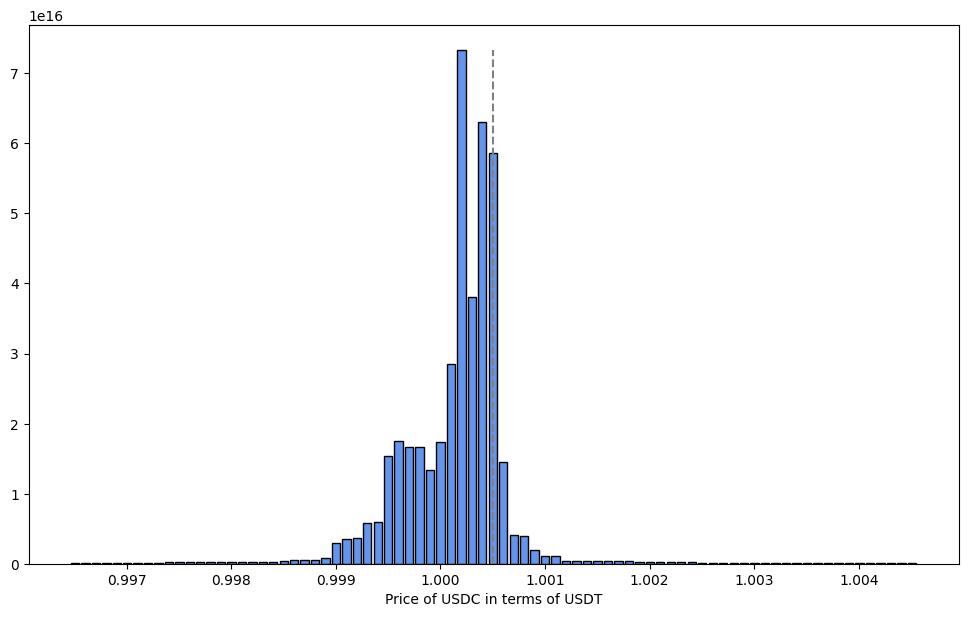

In [ ]:
plt.figure(figsize=(12, 7))
plt.bar(curve["price0"], curve["activeLiquidity"], width = 0.8*(curve["price0"].diff().median()), align="center", color = "cornflowerblue", edgecolor = "black")
plt.vlines(x=(1.0001)**current_tick, ymin=0, ymax=curve["activeLiquidity"].max(), color="grey",linestyle = "--", lw=1.5)
plt.xlabel(f"Price of {token0} in terms of {token1}")

## Get open liquidity positions

In [ ]:
describe_type("position")

,field,type,args
0,id,ID!,
1,owner,Bytes!,
2,pool,Pool!,
3,token0,Token!,
4,token1,Token!,
5,tickLower,Tick!,
6,tickUpper,Tick!,
7,liquidity,BigInt!,
8,depositedToken0,BigDecimal!,
9,depositedToken1,BigDecimal!,


In [ ]:
LIQUIDITY_QUERY = """
query GetLiquidityCurve($id: ID!) {
  positions(first:1000, id: $id, where : {pool: $id}) {
    id
    pool{ id }
    liquidity
    owner
    tickLower { tickIdx }
    tickUpper { tickIdx }
}
}
"""

In [ ]:
raw_pos = run_query(LIQUIDITY_QUERY, {"id": usdc_usdt_address})

positions = pd.DataFrame(raw_pos["positions"])
positions["tickLower"] = positions["tickLower"].apply(lambda x: int(x["tickIdx"]))
positions["tickUpper"] = positions["tickUpper"].apply(lambda x: int(x["tickIdx"]))
positions.head()

,id,liquidity,owner,pool,tickLower,tickUpper
0,1000425,0,0x18acced487c3b4432f9f9a36151d9ec0cd5a985c,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-3647,3562
1,1001700,0,0x0000000000000000000000000000000000000000,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-5,-1
2,1001766,0,0x0000000000000000000000000000000000000000,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-7,0
3,1001924,0,0x91dd5a744cfb55ccc1292922ba945e36b5ce5ddd,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-887272,887272
4,1002197,0,0x0000000000000000000000000000000000000000,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-6,-2


We should filter the 0 liquidity positions : 

In [ ]:
LIQUIDITY_QUERY = """
query GetLiquidityCurve($id: ID!) {
  positions(first:1000, id: $id, where : {pool: $id, liquidity_gt: 0}) {
    id
    pool{ id }
    liquidity
    owner
    tickLower { tickIdx }
    tickUpper { tickIdx }
}
}
"""

raw_pos = run_query(LIQUIDITY_QUERY, {"id": usdc_usdt_address})

positions = pd.DataFrame(raw_pos["positions"])
positions["tickLower"] = positions["tickLower"].apply(lambda x: int(x["tickIdx"]))
positions["tickUpper"] = positions["tickUpper"].apply(lambda x: int(x["tickIdx"]))
positions.liquidity = pd.to_numeric(positions.liquidity, errors="coerce")

Convert to a tick-by-tick liquidity :
- if a tick is inside [TickLower, TickUpper] it gets liquidity added

In [ ]:
def liquidity_curve_on_ticks(
    df: pd.DataFrame,
    peg_tick: int,
    half_width: int = 50,
    tick_spacing: int = 1,
    tick_lower_col: str = "tickLower",
    tick_upper_col: str = "tickUpper",
    liquidity_col: str = "liquidity",
) -> pd.DataFrame:
    """
    Build the *active liquidity* curve L(t) over ticks in [peg_tick-half_width, peg_tick+half_width],
    where a position contributes liquidity on [tickLower, tickUpper) (inclusive of lower, exclusive of upper).

    Returns a DataFrame with columns: tick, active_liquidity

    Notes:
      - If you want an exact curve, sample at tick_spacing=1 (or ensure your sampling includes all boundary ticks).
      - liquidity is assumed additive (same units as stored in the subgraph).
    """
    if df.empty:
        return pd.DataFrame({"tick": [], "active_liquidity": []})

    start = int(peg_tick) - int(half_width)
    end   = int(peg_tick) + int(half_width)

    x = df[[tick_lower_col, tick_upper_col, liquidity_col]].copy()
    x[tick_lower_col] = pd.to_numeric(x[tick_lower_col], errors="coerce").astype("Int64")
    x[tick_upper_col] = pd.to_numeric(x[tick_upper_col], errors="coerce").astype("Int64")
    # liquidity is often a big integer encoded as string
    x[liquidity_col] = pd.to_numeric(x[liquidity_col], errors="coerce").fillna(0).astype("int64")

    # keep only positions that overlap the range at all
    x = x[(x[tick_upper_col] > start) & (x[tick_lower_col] <= end)]
    if x.empty:
        ticks = list(range(start, end + 1, tick_spacing))
        return pd.DataFrame({"tick": ticks, "active_liquidity": [0] * len(ticks)})

    # initial liquidity active at 'start'
    initial = x[(x[tick_lower_col] <= start) & (x[tick_upper_col] > start)][liquidity_col].sum()

    # deltas inside (start, end]
    add = (
        x[(x[tick_lower_col] > start) & (x[tick_lower_col] <= end)]
        .groupby(tick_lower_col)[liquidity_col]
        .sum()
    )
    sub = (
        x[(x[tick_upper_col] > start) & (x[tick_upper_col] <= end)]
        .groupby(tick_upper_col)[liquidity_col]
        .sum()
        .mul(-1)
    )
    deltas = add.add(sub, fill_value=0).to_dict()  # tick -> net change at that tick

    ticks = list(range(start, end + 1, tick_spacing))

    active = []
    L = int(initial)
    for i, t in enumerate(ticks):
        if i > 0:
            L += int(deltas.get(t, 0))
        active.append(L)

    return pd.DataFrame({"tick": ticks, "active_liquidity": active})


In [ ]:
curve_from_pos = liquidity_curve_on_ticks(df = positions, peg_tick = current_tick, half_width = 40)

Text(0.5, 0, 'Price of USDC in terms of USDT')

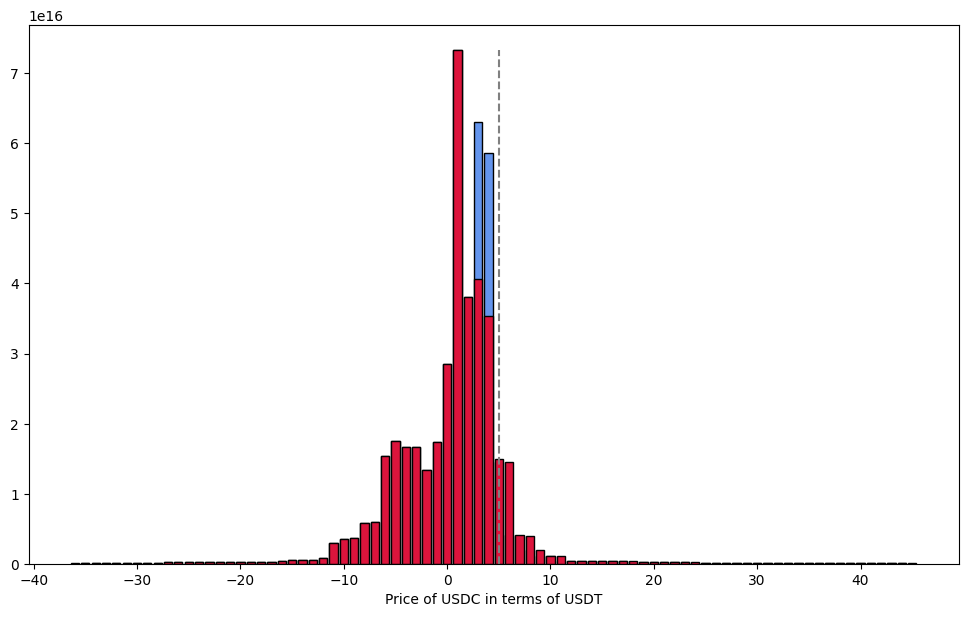

In [ ]:
plt.figure(figsize=(12, 7))
plt.bar(curve["tickIdx"]-1, curve["activeLiquidity"], width = 0.8, align="center", color = "cornflowerblue", edgecolor = "black")
plt.bar(curve_from_pos["tick"], curve_from_pos["active_liquidity"], width = 0.8, align="center", color = "crimson", edgecolor = "black")
plt.vlines(x=current_tick, ymin=0, ymax=curve["activeLiquidity"].max(), color="grey",linestyle = "--", lw=1.5)
plt.xlabel(f"Price of {token0} in terms of {token1}")

- The positions are missing some liquidity
- Some liquidity is minted directly on the pool, withouth going through Uniswap's NFPM contract
    - Mostly JIT liquidity and MEV bots

> MEV liquidity is added and removed in the same block, let's query recent mints/burns to see if we can identify MEV bots.

# Collecting Mint/Burn events and Identifying MEV bots

In [ ]:
# describe_type("mint")  
describe_type("burn")

,field,type,args
0,id,ID!,
1,transaction,Transaction!,
2,pool,Pool!,
3,token0,Token!,
4,token1,Token!,
5,timestamp,BigInt!,
6,owner,Bytes,
7,origin,Bytes!,
8,amount,BigInt!,
9,amount0,BigDecimal!,


Let's query the last mint events on the USDC/USDT pool :
- where pool address = USDC/USDT address
- order by decreasing timestamp

In [25]:
LIQUIDITY_QUERY = """
query GetMintsBurns($id: ID!) {
  mints(first:100, where : {pool: $id}, orderBy: timestamp, orderDirection: desc) {
    id
    owner
    origin
    sender
    amount0
    amount1
    timestamp
    tickLower { tickIdx }
    tickUpper { tickIdx }
    transaction {
      blockNumber
    }
}
}
"""

raw_mints = run_query(LIQUIDITY_QUERY, {"id": usdc_usdt_address})
mints_df = pd.DataFrame(raw_mints['mints'])
mints_df['blockNumber'] = mints_df['transaction'].apply(lambda x: x['blockNumber']).astype(int)
mints_df = mints_df.drop(columns=['transaction'])
mints_df

,amount0,amount1,id,origin,owner,sender,tickLower,tickUpper,timestamp,blockNumber
0,789915.894416,1092908.520178,0x7436f2fac9caf5af166933feb47cf97329a78a6005222f5d45cfd9d652bf6a66#1749743,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x1f2f10d1c40777ae1da742455c65828ff36df387,0x1f2f10d1c40777ae1da742455c65828ff36df387,4,5,1775025659,24783022
1,610532.110227,1092884.861969,0x937d24f8b699ca84f2773f7869332d90d0c3c2063606605be33c33dac624372d#1749725,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x1f2f10d1c40777ae1da742455c65828ff36df387,0x1f2f10d1c40777ae1da742455c65828ff36df387,4,5,1775024063,24782889
2,369977.050075,703456.6958,0xe138d902c082820f5eb36b0044424446345cc160b561cb6f3e247bd834e242b3#1749627,0x9b014d6893011ca3b049daa59b70554d8aa098f3,0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70,0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70,4,5,1775016107,24782229
3,1507839.516352,31216.212518,0xef529dc9c44cc551659563df2add75440e583f1ce717e4d30560dd923896a94e#1749617,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x1f2f10d1c40777ae1da742455c65828ff36df387,0x1f2f10d1c40777ae1da742455c65828ff36df387,5,6,1775015075,24782144
4,0,292281.443386,0x0e7c87f469e4b3e7a10ef18f5ac5ef18f6e8cafb70e4baf8929f64b0cfa9e63f#1749610,0x9fd758606ae8b98d5a4844281ccc4432b94feb65,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,1,5,1775014367,24782086
...,...,...,...,...,...,...,...,...,...,...
95,2725,74691.189092,0xf371f672f4b112b65410280acc1944468280230de818ea6ca4cd8d29961fa2c5#1745963,0xd69044dfcd03e34d8824a28f1c6662d17861cbcd,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,4,5,1774647071,24751596
96,8.80317,91.2376,0x985693ac1ec93535231b90bc7893879a1e80670ed829fcc9e1df23caf98f48c2#1745945,0xc29ea541a77e38aa6a3056a3859313c08efea501,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,-6,6,1774644911,24751417
97,435049.49303,1085214.845717,0x03d92a7c543433d361c683e03bc22c0644a7534d42fa4e8203848007f20b122e#1745918,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x1f2f10d1c40777ae1da742455c65828ff36df387,0x1f2f10d1c40777ae1da742455c65828ff36df387,4,5,1774643219,24751277
98,436483.415075,1085105.64353,0xa2e5d395e7b6158394f6bd4b1153adab882cdce17c40e490a8240bff7c3acadd#1745891,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x1f2f10d1c40777ae1da742455c65828ff36df387,0x1f2f10d1c40777ae1da742455c65828ff36df387,4,5,1774641239,24751112


- Since the events tracked are mints owner == sender
- Owner is the smart contract calling mint on the pool
- Origin is the wallet (EOA) owning the liquidity

In [26]:
mints_df.owner.value_counts().head(10)

owner
0xc36442b4a4522e871399cd717abdd847ab11fe88    46
0x1f2f10d1c40777ae1da742455c65828ff36df387    44
0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70     6
0x28ac01d4790ed04b378ca32c90e443b3cb6358cd     2
0x8c209c15835cccb2984701b52651d2c8d83aa442     2
Name: count, dtype: int64

> A visit to etherscan shows that 0xc36442b4a4522e871399cd717abdd847ab11fe88 is the address of the uniswap positions manager
https://etherscan.io/address/0xc36442b4a4522e871399cd717abdd847ab11fe88

- Let's update our query ! (let's also query burns)

In [27]:
nfpm = "0xc36442b4a4522e871399cd717abdd847ab11fe88".lower()
LIQUIDITY_QUERY = """
query GetMintsBurns($id: ID!, $nfpm: String!) {
  mints(first:100, where : {pool: $id, owner_not: $nfpm}, orderBy: timestamp, orderDirection: desc) {
    id
    owner
    origin
    amount
    amount0
    amount1
    tickLower { tickIdx }
    tickUpper { tickIdx }
    transaction {
      blockNumber
    }
}
  burns(first:100, where : {pool: $id, owner_not: $nfpm}, orderBy: timestamp, orderDirection: desc) {
    id
    owner
    origin
    amount
    amount0
    amount1
    tickLower { tickIdx }
    tickUpper { tickIdx }
    transaction {
      blockNumber
    }
}
}
"""

raw_mints_burns = run_query(LIQUIDITY_QUERY, {"id": usdc_usdt_address, "nfpm": nfpm})
mints_df = pd.DataFrame(raw_mints_burns['mints'])
mints_df['blockNumber'] = mints_df['transaction'].apply(lambda x: x['blockNumber']).astype(int)
mints_df = mints_df.drop(columns=['transaction'])
burns_df = pd.DataFrame(raw_mints_burns['burns'])
burns_df['blockNumber'] = burns_df['transaction'].apply(lambda x: x['blockNumber']).astype(int)
burns_df = burns_df.drop(columns=['transaction'])

In [28]:
mints_df.owner.value_counts().head(10)

owner
0x1f2f10d1c40777ae1da742455c65828ff36df387    81
0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70    12
0x28ac01d4790ed04b378ca32c90e443b3cb6358cd     4
0x8c209c15835cccb2984701b52651d2c8d83aa442     3
Name: count, dtype: int64

Now etherscan shows that the most active SC is a known MEV bot : https://etherscan.io/address/0x1f2f10d1c40777ae1da742455c65828ff36df387

- let's check its behavior, looking at the last mint:

In [29]:
last_mint = mints_df.query('owner == "0x1f2f10d1c40777ae1da742455c65828ff36df387"').iloc[-1]
last_mint

amount                                                                  14907904582746112
amount0                                                                     200049.661208
amount1                                                                     545326.875189
id             0xc7860c9ed1ab2d73726a2dbe7d5214c5db485d9333e1f327ccf39dd23f9eae63#1743463
origin                                         0xae2fc483527b8ef99eb5d9b44875f005ba1fae13
owner                                          0x1f2f10d1c40777ae1da742455c65828ff36df387
tickLower                                                                               1
tickUpper                                                                               2
blockNumber                                                                      24737050
Name: 99, dtype: object

There is a corresponding burn of the same amount of liquidity on the same block:

In [30]:
last_burn = burns_df.query('owner == "0x1f2f10d1c40777ae1da742455c65828ff36df387"').iloc[-1]
last_burn

amount                                                                  14907904582746112
amount0                                                                     200965.586115
amount1                                                                     544410.791731
id             0x34f093bb41715b0734d4e4a796e7edd69b2519398987731821644d3a892b9dd8#1743465
origin                                         0xae2fc483527b8ef99eb5d9b44875f005ba1fae13
owner                                          0x1f2f10d1c40777ae1da742455c65828ff36df387
tickLower                                                                               1
tickUpper                                                                               2
blockNumber                                                                      24737050
Name: 98, dtype: object

> Compute what percentage of active liquidity at Active Tick this MEV bot had 

- query the liquidity curve (specify the correct blockNumber)
- Verify that this position overlaps the price at that time
- Find proportion of active liquidity

# Polymarket Data Collection

- Polymarket indexes several subgraphs for different aspects of the platform; subgraphs are publicly hosted on goldsky
- Polymarket also hosts an API for trading/data collection on the centralized parts of the platform. https://docs.polymarket.com/api-reference/introduction
- Data collection needs to be done with subgraphs and the gamma API in conjunction


> Since the data is more complex on Polymarket, we give some basic ideas on collection and leave more complex analysis for later 

In [31]:
# Set up environment
GAMMA_API = "https://gamma-api.polymarket.com"
CLOB_API = "https://clob.polymarket.com"
GOLDSKY_PNL = "https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/pnl-subgraph/0.0.14/gn"
GOLDSKY_OI = "https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/oi-subgraph/0.0.6/gn"
GOLDSKY_ORDER = "https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/orderbook-subgraph/0.0.1/gn"
session = requests.Session()

- let's view the fields on the Polymarket subgraph:

#### Pnl subgraph

In [32]:
schema = run_query(INTROSPECTION_QUERY, url=GOLDSKY_PNL)["__schema"]
print("Query type:", schema["queryType"]["name"])
print("Number of schema types:", len(schema["types"]))
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

Query type: Query
Number of schema types: 30


,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
5,conditions,[Condition!]!,Condition,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,fpmms,[FPMM!]!,FPMM,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
3,negRiskEvents,[NegRiskEvent!]!,NegRiskEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
1,userPositions,[UserPosition!]!,UserPosition,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
8,_meta,_Meta_,_Meta_,block,False,True,False,False,False
4,condition,Condition,Condition,"id, block, subgraphError",False,True,False,False,False
6,fpmm,FPMM,FPMM,"id, block, subgraphError",False,True,False,False,False
2,negRiskEvent,NegRiskEvent,NegRiskEvent,"id, block, subgraphError",False,True,False,False,False
0,userPosition,UserPosition,UserPosition,"id, block, subgraphError",False,True,False,False,False


In [33]:
describe_type("condition")

,field,type,args
0,id,ID!,
1,positionIds,[BigInt!]!,
2,payoutNumerators,[BigInt!]!,
3,payoutDenominator,BigInt!,


#### Open Interest

In [34]:
schema = run_query(INTROSPECTION_QUERY, url=GOLDSKY_OI)["__schema"]
print("Query type:", schema["queryType"]["name"])
print("Number of schema types:", len(schema["types"]))
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

Query type: Query
Number of schema types: 30


,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
1,conditions,[Condition!]!,Condition,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,globalOpenInterests,[GlobalOpenInterest!]!,GlobalOpenInterest,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
5,marketOpenInterests,[MarketOpenInterest!]!,MarketOpenInterest,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
3,negRiskEvents,[NegRiskEvent!]!,NegRiskEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
8,_meta,_Meta_,_Meta_,block,False,True,False,False,False
0,condition,Condition,Condition,"id, block, subgraphError",False,True,False,False,False
6,globalOpenInterest,GlobalOpenInterest,GlobalOpenInterest,"id, block, subgraphError",False,True,False,False,False
4,marketOpenInterest,MarketOpenInterest,MarketOpenInterest,"id, block, subgraphError",False,True,False,False,False
2,negRiskEvent,NegRiskEvent,NegRiskEvent,"id, block, subgraphError",False,True,False,False,False


In [35]:
describe_type("marketOpenInterest")

,field,type,args
0,id,ID!,
1,amount,BigInt!,


#### Orders

In [36]:
schema = run_query(INTROSPECTION_QUERY, url=GOLDSKY_ORDER)["__schema"]
print("Query type:", schema["queryType"]["name"])
print("Number of schema types:", len(schema["types"]))
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

Query type: Query
Number of schema types: 33


,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
1,marketDatas,[MarketData!]!,MarketData,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
3,orderFilledEvents,[OrderFilledEvent!]!,OrderFilledEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,orderbooks,[Orderbook!]!,Orderbook,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
5,ordersMatchedEvents,[OrdersMatchedEvent!]!,OrdersMatchedEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
9,ordersMatchedGlobals,[OrdersMatchedGlobal!]!,OrdersMatchedGlobal,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
10,_meta,_Meta_,_Meta_,block,False,True,False,False,False
0,marketData,MarketData,MarketData,"id, block, subgraphError",False,True,False,False,False
2,orderFilledEvent,OrderFilledEvent,OrderFilledEvent,"id, block, subgraphError",False,True,False,False,False
6,orderbook,Orderbook,Orderbook,"id, block, subgraphError",False,True,False,False,False
4,ordersMatchedEvent,OrdersMatchedEvent,OrdersMatchedEvent,"id, block, subgraphError",False,True,False,False,False


In [37]:
describe_type("marketData")

,field,type,args
0,id,ID!,
1,condition,String!,
2,outcomeIndex,BigInt,


### Basic queries

In [70]:
SUBGRAPH_ID = "4LkKSgkqijUccYMYMYUPtjXswrdK3xipPMfs3fa7gfef"
API_KEY = os.getenv("GRAPH_API_KEY") 
SUBGRAPH_PNL = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"

In [72]:
schema = run_query(INTROSPECTION_QUERY, url=SUBGRAPH_PNL)["__schema"]

In [75]:
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
3,accounts,[Account!]!,Account,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
5,collaterals,[Collateral!]!,Collateral,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,conditions,[Condition!]!,Condition,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
33,dailyStats_collection,[DailyStats!]!,DailyStats,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
1,globals,[Global!]!,Global,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
11,marketPositions,[MarketPosition!]!,MarketPosition,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
13,marketProfits,[MarketProfit!]!,MarketProfit,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
9,markets,[Market!]!,Market,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
29,merges,[Merge!]!,Merge,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
23,orderFilledEvents,[OrderFilledEvent!]!,OrderFilledEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True


In [84]:
POS_QUERY = """
query getUserPositions($first: Int!) {
  tokenPositions(first: $first, orderBy: amount, orderDirection: desc) {
    id
    user 
    tokenId
    amount
    avgPrice
    realizedPnl
    totalBought
}
}
"""

raw = run_query(POS_QUERY, {"first": 100}, url=SUBGRAPH_PNL)
pos_df= pd.DataFrame(raw['tokenPositions'])

In [85]:
pos_df

,amount,avgPrice,id,realizedPnl,tokenId,totalBought
0,21873712657324,990600,0xc6587b11a2209e46dfe3928b31c5514a8e33b784-24635636911615866092589652362670811323984202357282728474473612545495782013438,3776108569,24635636911615866092589652362670811323984202357282728474473612545495782013438,21983718966572
1,12516018736919,992564,0xfffe4013adfe325c6e02d36dc66e091f5476f52c-104468264438118085465761163263611745362235161579898771567536629365715258090512,8451834863,104468264438118085465761163263611745362235161579898771567536629365715258090512,15217728494290
2,8954170736616,2967,0xec445c8bee160281558ebb9b083ac0025006c92b-108988271800978168213949343685406694292284061166193819357568013088568150075789,-11711695501,108988271800978168213949343685406694292284061166193819357568013088568150075789,9244437800694
3,8895325024793,6134,0x397b0530e54aa4c46be0adc98478b62f4f2ba667-108988271800978168213949343685406694292284061166193819357568013088568150075789,0,108988271800978168213949343685406694292284061166193819357568013088568150075789,8895325024793
4,7689512931705,983506,0x889e7f0464c72eb8cda1525ebc12b6aaba9d09e0-34379581789895528560281218239759280237277305372978794324822777438824410172683,1244594513,34379581789895528560281218239759280237277305372978794324822777438824410172683,7796152916296
...,...,...,...,...,...,...
95,2745662116097,807485,0x2a2c53bd278c04da9962fcf96490e17f3dfb9bc1-64024535238733125841763079646903083308933520686600379980978305341937621090800,10396776778,64024535238733125841763079646903083308933520686600379980978305341937621090800,2786020696097
96,2736197045924,969758,0xc6587b11a2209e46dfe3928b31c5514a8e33b784-36202754231387097306325702546396014827944798202465293616453871341350603385788,24520492076,36202754231387097306325702546396014827944798202465293616453871341350603385788,3064091145924
97,2720070363222,675220,0x14964aefa2cd7caff7878b3820a690a03c5aa429-46434110155841033529384949983718980438706543876953886750286883506638610790525,11956582,46434110155841033529384949983718980438706543876953886750286883506638610790525,2722470243222
98,2708106086510,393303,0x1d04d5b13ba31ca6f3b9526ded9cfe43519ced05-100180144441344516029196380796541367659775855719836481414910537902981560041958,0,100180144441344516029196380796541367659775855719836481414910537902981560041958,2708106086510


In [81]:
OI_QUERY = """
query getOI($first: Int!) {
  marketOpenInterests(first: $first) {
    id
    amount
}
}
"""

raw = run_query(OI_QUERY, {"first": 10}, url=GOLDSKY_OI)
oi_df = pd.DataFrame(raw['marketOpenInterests'])
oi_df['amount'] = pd.to_numeric(oi_df['amount'])
oi_df

,id,amount
0,0x00000977017fa72fb6b1908ae694000d3b51f442c2552656b10bdbbfd16ff707,826703560
1,0x00005c113846891686d99ff1d145ded8bdccfa028df0fdf15d66f11d176c49b1,0
2,0x00008da19716178aee4234373ea8702fabd5088d030e7d2b3b38a3637fb69167,22991178
3,0x0000a3aa2ac9a909841538e97750d8cf5ef95fdf46b74a3d670e50771c58bbed,0
4,0x0000bd14c46a76b3cf2d7bdb48e39f21ecef57130b0ad8681e51d938e5715296,18846
5,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7f9e9be6e9079e1fb3d4f,23154
6,0x0000e7c9418bd82e7c7b1236952030abcefcdfff6e13fabc87eda3147fae6936,15931200
7,0x000115170c7db87d5af2ab8eb3112d39699722fd936b682714d6fd9a4f595a5c,0
8,0x000122ff0329632a7e264073891260ee3dbcd013f3f57bd9a39f81633d3c7587,2000
9,0x000149d7a2971f4ba69343b6ebc8b5d76a29b2f20caa7b7041ae2f2da0a448f3,4923


### Top winners by PnL

Polymarket keeps in the api the top winners by period for its leaderboard:
- We can look at the biggest winners and what they trade

In [86]:
wallets_df = pd.DataFrame(requests.get('https://data-api.polymarket.com/v1/leaderboard?category=OVERALL&timePeriod=MONTH&orderBy=PNL&limit=5', timeout=30).json())

In [87]:
wallets_df

,rank,proxyWallet,userName,xUsername,verifiedBadge,vol,pnl,profileImage
0,1,0x492442eab586f242b53bda933fd5de859c8a3782,0x492442EaB586F242B53bDa933fD5dE859c8A3782-1766317541188,,False,1.386230e+06,4.306131e+06,
1,2,0x02227b8f5a9636e895607edd3185ed6ee5598ff7,HorizonSplendidView,,False,0.000000e+00,4.016108e+06,
2,3,0xefbc5fec8d7b0acdc8911bdd9a98d6964308f9a2,reachingthesky,,False,0.000000e+00,3.742635e+06,
3,4,0xc2e7800b5af46e6093872b177b7a5e7f0563be51,beachboy4,,False,1.894429e+06,3.660900e+06,
4,5,0x019782cab5d844f02bafb71f512758be78579f3c,majorexploiter,,False,0.000000e+00,2.416975e+06,


- Users are indentified by their proxy wallets
- Let's look at number 1 on the leaderboard : https://polygonscan.com/address/0x492442eab586f242b53bda933fd5de859c8a3782#tokentxns

In [102]:
POS_QUERY = """
query getUserPositions($first: Int!, $user: String!) {
  tokenPositions(first: $first, where: {user: $user, totalBought_gt: 0}) {
    id
    user
    tokenId
    amount
    avgPrice
    realizedPnl
    totalBought
  }
}
"""

user_address = wallets_df["proxyWallet"].iloc[0].lower()   # subgraph stores lowercase
raw = run_query(POS_QUERY, {"first": 200, "user": user_address}, url=SUBGRAPH_PNL)
pos_df = pd.DataFrame(raw["tokenPositions"])

for col in ["realizedPnl", "amount", "avgPrice", "totalBought"]:
    pos_df[col] = pd.to_numeric(pos_df[col]) / 1e6

top_pos = pos_df.sort_values("totalBought", ascending=False).reset_index(drop=True)

In [ ]:
POS_QUERY = """
query getUserPositions($first: Int!, $user: String!) {
  userPositions(first: $first, where: {user: $user, totalBought_gt: 0}) {
    id
    user
    tokenId
    amount
    avgPrice
    realizedPnl
    totalBought
  }
}
"""

user_address = wallets_df["proxyWallet"].iloc[0].lower()   # subgraph stores lowercase
raw = run_query(POS_QUERY, {"first": 200, "user": user_address}, url=GOLDSKY_PNL)
pos_df = pd.DataFrame(raw["userPositions"])

for col in ["realizedPnl", "amount", "avgPrice", "totalBought"]:
    pos_df[col] = pd.to_numeric(pos_df[col]) / 1e6


In [103]:
unique_tokens = top_pos['tokenId'].unique()
print(f"Looking up {len(unique_tokens)} unique token IDs on Gamma API...")

token_to_market = {}
for i, tid in enumerate(unique_tokens):
    try:
        r = requests.get(f"{GAMMA_API}/markets", params={"clob_token_ids": tid, "limit": 1}, timeout=30)
        r.raise_for_status()
        markets = r.json()
        if markets:
            m = markets[0]
            token_to_market[tid] = {
                'question': m.get('question'),
                'slug': m.get('slug'),
                'conditionId': m.get('conditionId'),
                'market_id': m.get('id'),
            }
        else:
            token_to_market[tid] = {'question': None, 'slug': None, 'conditionId': None, 'market_id': None}
    except Exception as e:
        token_to_market[tid] = {'question': f'Error: {e}', 'slug': None, 'conditionId': None, 'market_id': None}
    time.sleep(0.05)
    if (i + 1) % 50 == 0:
        print(f"  ...{i + 1}/{len(unique_tokens)} done")

market_df = pd.DataFrame.from_dict(token_to_market, orient='index').reset_index().rename(columns={'index': 'tokenId'})
top_pos_matched = top_pos.merge(market_df, on='tokenId', how='left')

matched = top_pos_matched['question'].notna().sum()
print(f"Matched: {matched} / {len(top_pos)} positions")

Looking up 200 unique token IDs on Gamma API...
  ...50/200 done
  ...100/200 done
  ...150/200 done
  ...200/200 done
Matched: 200 / 200 positions


In [105]:
top_pos_matched

,amount,avgPrice,id,realizedPnl,tokenId,totalBought,question,slug,conditionId,market_id
0,745160.898569,0.510000,0x492442eab586f242b53bda933fd5de859c8a3782-12035465076229752781908256263963783360216277908549884664476516616806440930892,0.0,12035465076229752781908256263963783360216277908549884664476516616806440930892,745160.898569,Spread: Trail Blazers (-16.5),nba-was-por-2026-03-29-spread-home-16pt5,0x0f667610ed65264e96d55ec467e22f93bfc6e58ffc7cafae55f2d570c14692d3,1768511
1,701091.220000,0.509963,0x492442eab586f242b53bda933fd5de859c8a3782-10811886714933354532416443920548249155010684228434779164799387548764331111087,0.0,10811886714933354532416443920548249155010684228434779164799387548764331111087,701091.220000,Spread: Thunder (-14.5),nba-mia-okc-2026-01-11-spread-home-14pt5,0xe1ea363c221070b5d50d5b0ade71e4ac59c2139ca41b36ff419576cb856c4707,1156448
2,693765.450000,0.471879,0x492442eab586f242b53bda933fd5de859c8a3782-103664969483446045373145453577272914883474012098708947167939881582961848381690,0.0,103664969483446045373145453577272914883474012098708947167939881582961848381690,693765.450000,Delaware State Hornets vs. Howard Bison: O/U 131.5,cbb-delst-howrd-2026-01-12-total-131pt5,0x040bdc28edda1cde58b2a13122fd21dee958e2d3901e6ac4f13618b1c01d0b9f,1168572
3,684723.960000,0.519997,0x492442eab586f242b53bda933fd5de859c8a3782-12767913720046768926939275146212415145760484773667230755868724189803289465010,0.0,12767913720046768926939275146212415145760484773667230755868724189803289465010,684723.960000,Towson Tigers vs. North Carolina A&T Aggies: O/U 139.5,cbb-tows-ncat-2026-01-24-total-139pt5,0x41206039343712e46aacc2e4e4b19cd1cc7c2d17f3fc70cbe97bbcc3ed86ccd4,1255196
4,679973.880000,0.519883,0x492442eab586f242b53bda933fd5de859c8a3782-108646050986308824177766249683324502154066203804609585574296921278022636427741,0.0,108646050986308824177766249683324502154066203804609585574296921278022636427741,679973.880000,Louisiana-Monroe Warhawks vs. Appalachian State Mountaineers: O/U 144.5,cbb-lamon-applst-2026-01-23-total-144pt5,0x75c5d5ff39ff698dae1bee44366c0136bca91aa178c8f4062140a94e71ee03f6,1245589
...,...,...,...,...,...,...,...,...,...,...
195,20.000000,0.400000,0x492442eab586f242b53bda933fd5de859c8a3782-107805022871263356127262008957400937944980692933676593308959945112019909157570,0.0,107805022871263356127262008957400937944980692933676593308959945112019909157570,20.000000,Spread: FC Bayern München (-2.5),bun-koe-bay-2026-01-14-spread-away-2pt5,0x25dff6b41a5e0a35b439c4ea412f95e2a035485d71f4fe2f0091e443498b052c,1079086
196,16.425530,0.530000,0x492442eab586f242b53bda933fd5de859c8a3782-101768084808725372994602419620461773240986662179261759395833107449126652978442,0.0,101768084808725372994602419620461773240986662179261759395833107449126652978442,16.425530,Maine Black Bears vs. Vermont Catamounts: O/U 129.5,cbb-maine-verm-2026-01-15-total-129pt5,0xf8d3039ede71c490668f0be88c525a9cbab169293b84a896d903ecf4cfa16d5d,1190860
197,7.290000,0.520000,0x492442eab586f242b53bda933fd5de859c8a3782-100811345550984967291443152848457664713937036362298568633183862968281722368082,0.0,100811345550984967291443152848457664713937036362298568633183862968281722368082,7.290000,Kennesaw State Owls vs. Louisiana Tech Bulldogs: O/U 142.5,cbb-kenest-loutch-2026-01-23-total-142pt5,0x6437aba353f50971181bdbe9a86ee43fcbbb61e8245f03b7a2d29eac0ead949f,1249818
198,5.000000,0.470000,0x492442eab586f242b53bda933fd5de859c8a3782-101411723825116728356398099695733000761421822637434146584014770449123797560419,0.0,101411723825116728356398099695733000761421822637434146584014770449123797560419,5.000000,Kings vs. Cavaliers: O/U 234.5,nba-sac-cle-2026-01-23-total-234pt5,0x097e0767e0711f82be0a26a45794300b43218c7bf08d2afd120ed6eecaae68b1,1245339
